In [ ]:
# ======================================================================
# MODÜL A — AKADEMİK MAKALE Q-KATEGORİSİ SINIFLANDIRMASI
# ======================================================================
# Amaç: 4 sınıflı (Q1/Q2/Q3/Q4) sınıflandırma; içerikten + bibliyometrik
# özelliklerden Q tahmini.
#
# Veri kaynağı:
#   - data/shared_outputs/base_features.pkl  (university YOK — ana senaryo)
#   - data/shared_outputs/ood_features.pkl   (univ_freq encoding eklenmiş)
#   - data/shared_outputs/train_step2.parquet, test_step2.parquet
#
# Notebook 02'de hazırlanan feature setleri:
#   - TF-IDF (50K boyut, sparse)
#   - SPECTER2 (768 boyut, dense)
#   - Yapısal/kategorik (269 boyut: main_cat one-hot + sayısal + bool)
#   - Yazar istatistikleri (5 boyut)
#
# 3 senaryo (kurumsal etki ölçümü için):
#   (S1) OOD-kurumsuz   : test=Bahçeşehir (orijinal OOD), university bilgisi kullanılmaz
#   (S2) OOD+univ_freq  : test=Bahçeşehir, ama university frekans encoding'i feature olarak eklenmiş
#                         Bahçeşehir için "ortalama Türk üni" profili kullanılır
#   (S3) Random         : train ve test'i karıştır, %80/%20 stratified split
#                         → kurumsal homojenlik altında modelin tavan performansı
#
# Modeller: Dummy, main_cat baseline, Logistic Regression, Random Forest,
#           XGBoost, LightGBM
#
# Sızıntı kuralları:
#   - cited_by_count feature olarak KULLANILMAZ (gelecek bilgi)
#   - journal_name, publisher, ISSN KULLANILMAZ (Q'dan türetildi, tautoloji)
#   - university (S1'de): hiç verilmez. (S2'de): sadece encoded olarak.
#
# Hyperparameter tuning yapılmıyor — literatür default'larıyla
# (sınırlılıklar bölümünde belgelenecek)
# ======================================================================

import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

SHARED = Path(r"C:\Users\Salih\Desktop\proje\data\shared_outputs")

# 1) Bundle'ları yükle
with open(SHARED / "base_features.pkl", "rb") as f:
    base = pickle.load(f)
with open(SHARED / "ood_features.pkl", "rb") as f:
    ood = pickle.load(f)

# 2) Orijinal DataFrame'ler (görselleştirme + main_cat baseline için)
tr_df = pd.read_parquet(SHARED / "train_step2.parquet").reset_index(drop=True)
te_df = pd.read_parquet(SHARED / "test_step2.parquet").reset_index(drop=True)

y_le = base["y_encoder"]
classes = list(y_le.classes_)
print(f"Sınıflar: {classes}")
print(f"Train: {base['y_train'].shape[0]} makale, Test: {base['y_test'].shape[0]} makale (Bahçeşehir OOD)")

# 3) Feature set boyutları (kontrol)
print(f"\nFeature setleri:")
print(f"  TF-IDF    : train {base['tfidf_train'].shape}, test {base['tfidf_test'].shape}")
print(f"  SPECTER2  : train {base['specter2_train'].shape}, test {base['specter2_test'].shape}")
print(f"  Struct(S1): train {base['struct_train'].shape}, test {base['struct_test'].shape}  ← university YOK")
print(f"  Struct(S2): train {ood['struct_train'].shape}, test {ood['struct_test'].shape}   ← univ_freq eklenmiş")
print(f"  Author    : train {base['author_train'].shape}, test {base['author_test'].shape}")

# 4) Sanity check — y_train ve y_test eşleşmesi
assert base["y_train"].shape[0] == tr_df.shape[0], "y_train ile train_df uyuşmuyor"
assert base["y_test"].shape[0]  == te_df.shape[0], "y_test ile test_df uyuşmuyor"
assert (base["y_train"] == ood["y_train"]).all(), "base ve ood bundle'larda y_train farklı"
print("\nSanity check geçti.")

# 5) Q dağılımı (train vs test) — bunu A.9'da kullanırız
print(f"\nTrain Q dağılımı:")
for q, c in zip(classes, np.bincount(base["y_train"])):
    print(f"  {q}: {c} ({c/len(base['y_train'])*100:.1f}%)")
print(f"\nTest Q dağılımı (Bahçeşehir):")
for q, c in zip(classes, np.bincount(base["y_test"])):
    print(f"  {q}: {c} ({c/len(base['y_test'])*100:.1f}%)")

Sınıflar: ['Q1', 'Q2', 'Q3', 'Q4']
Train: 21303 makale, Test: 807 makale (Bahçeşehir OOD)

Feature setleri:
  TF-IDF    : train (21303, 50000), test (807, 50000)
  SPECTER2  : train (21303, 768), test (807, 768)
  Struct(S1): train (21303, 269), test (807, 269)  ← university YOK
  Struct(S2): train (21303, 274), test (807, 274)   ← univ_freq eklenmiş
  Author    : train (21303, 5), test (807, 5)

Sanity check geçti.

Train Q dağılımı:
  Q1: 5365 (25.2%)
  Q2: 5552 (26.1%)
  Q3: 4826 (22.7%)
  Q4: 5560 (26.1%)

Test Q dağılımı (Bahçeşehir):
  Q1: 159 (19.7%)
  Q2: 211 (26.1%)
  Q3: 191 (23.7%)
  Q4: 246 (30.5%)


In [2]:
from scipy.sparse import hstack, csr_matrix, vstack
from sklearn.model_selection import train_test_split

# Birleşik matris üreten yardımcı fonksiyon
def combine_features(tfidf, specter, struct, author):
    return hstack([
        tfidf,
        csr_matrix(specter),
        csr_matrix(struct),
        csr_matrix(author),
    ]).tocsr()

# ----------------------------------------------------------------------
# S1: OOD-kurumsuz (ana senaryo) — base bundle
# ----------------------------------------------------------------------
X_S1_train = combine_features(
    base["tfidf_train"], base["specter2_train"],
    base["struct_train"], base["author_train"]
)
X_S1_test = combine_features(
    base["tfidf_test"], base["specter2_test"],
    base["struct_test"], base["author_test"]
)
y_S1_train = base["y_train"]
y_S1_test  = base["y_test"]

# ----------------------------------------------------------------------
# S2: OOD + univ_freq encoding — ood bundle
# ----------------------------------------------------------------------
X_S2_train = combine_features(
    ood["tfidf_train"], ood["specter2_train"],
    ood["struct_train"], ood["author_train"]
)
X_S2_test = combine_features(
    ood["tfidf_test"], ood["specter2_test"],
    ood["struct_test"], ood["author_test"]
)
y_S2_train = ood["y_train"]
y_S2_test  = ood["y_test"]

# ----------------------------------------------------------------------
# S3: Random stratified split — train+test birleştir, yeniden böl
#     base bundle kullanılır (university yok), kurumsal etki olmadan tavan ölçümü
# ----------------------------------------------------------------------
X_S3_full = vstack([X_S1_train, X_S1_test]).tocsr()
y_S3_full = np.concatenate([y_S1_train, y_S1_test])

# Stratified %80/%20
idx_all = np.arange(X_S3_full.shape[0])
idx_train_S3, idx_test_S3 = train_test_split(
    idx_all, test_size=0.20, stratify=y_S3_full, random_state=42
)
X_S3_train = X_S3_full[idx_train_S3]
X_S3_test  = X_S3_full[idx_test_S3]
y_S3_train = y_S3_full[idx_train_S3]
y_S3_test  = y_S3_full[idx_test_S3]

# ----------------------------------------------------------------------
# Özet tablo
# ----------------------------------------------------------------------
scenarios = {
    "S1_OOD_kurumsuz":   (X_S1_train, X_S1_test, y_S1_train, y_S1_test),
    "S2_OOD_univ_freq":  (X_S2_train, X_S2_test, y_S2_train, y_S2_test),
    "S3_Random_strat":   (X_S3_train, X_S3_test, y_S3_train, y_S3_test),
}

print("="*70)
print("3 SENARYO ÖZET")
print("="*70)
for name, (Xtr, Xte, ytr, yte) in scenarios.items():
    print(f"\n{name}:")
    print(f"  X_train: {Xtr.shape}, X_test: {Xte.shape}")
    print(f"  y_train dağılımı: {dict(zip(classes, np.bincount(ytr)))}")
    print(f"  y_test  dağılımı: {dict(zip(classes, np.bincount(yte)))}")

# Test eşitliği sanity (S1 ve S2 testleri Bahçeşehir, S3 farklı)
print(f"\nS1 ve S2 test setleri özdeş (Bahçeşehir): {(y_S1_test == y_S2_test).all()}")
print(f"S3 test seti karışık: {len(y_S3_test)} makale, Bahçeşehir dahil tüm üniversitelerden")

3 SENARYO ÖZET

S1_OOD_kurumsuz:
  X_train: (21303, 51042), X_test: (807, 51042)
  y_train dağılımı: {'Q1': 5365, 'Q2': 5552, 'Q3': 4826, 'Q4': 5560}
  y_test  dağılımı: {'Q1': 159, 'Q2': 211, 'Q3': 191, 'Q4': 246}

S2_OOD_univ_freq:
  X_train: (21303, 51047), X_test: (807, 51047)
  y_train dağılımı: {'Q1': 5365, 'Q2': 5552, 'Q3': 4826, 'Q4': 5560}
  y_test  dağılımı: {'Q1': 159, 'Q2': 211, 'Q3': 191, 'Q4': 246}

S3_Random_strat:
  X_train: (17688, 51042), X_test: (4422, 51042)
  y_train dağılımı: {'Q1': 4419, 'Q2': 4610, 'Q3': 4014, 'Q4': 4645}
  y_test  dağılımı: {'Q1': 1105, 'Q2': 1153, 'Q3': 1003, 'Q4': 1161}

S1 ve S2 test setleri özdeş (Bahçeşehir): True
S3 test seti karışık: 4422 makale, Bahçeşehir dahil tüm üniversitelerden


In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Sonuçları toplayacağımız global dictionary
results = {s: {} for s in scenarios.keys()}

# ----------------------------------------------------------------------
# Baseline 1: Dummy (stratified)
# ----------------------------------------------------------------------
print("BASELINE 1: DUMMY (stratified random)")
for name, (Xtr, Xte, ytr, yte) in scenarios.items():
    dummy = DummyClassifier(strategy="stratified", random_state=42).fit(Xtr, ytr)
    y_pred = dummy.predict(Xte)
    acc = accuracy_score(yte, y_pred)
    f1m = f1_score(yte, y_pred, average="macro")
    f1c = f1_score(yte, y_pred, average=None)
    results[name]["Dummy"] = {
        "acc": acc, "macro_f1": f1m,
        "per_class_f1": dict(zip(classes, f1c)),
        "y_pred": y_pred,
    }
    print(f"\n[{name}] acc={acc:.4f}, macro_f1={f1m:.4f}")
    print(f"   per-class F1: {dict(zip(classes, [round(x,3) for x in f1c]))}")

# ----------------------------------------------------------------------
# Baseline 2: main_cat majority Q
# ----------------------------------------------------------------------
print("BASELINE 2: MAIN_CAT MAJORITY Q")

def maincat_baseline(train_df, train_idx, test_df, test_idx, y_le):
    """main_cat -> en sık Q, bilinmeyen kategori için global majority."""
    train_sub = train_df.iloc[train_idx] if train_idx is not None else train_df
    test_sub  = test_df.iloc[test_idx]  if test_idx  is not None else test_df
    maincat_to_q = train_sub.groupby("main_cat")["modded_Q_category"].agg(
        lambda x: x.value_counts().idxmax()
    )
    global_majority = train_sub["modded_Q_category"].value_counts().idxmax()
    y_pred_str = test_sub["main_cat"].map(maincat_to_q).fillna(global_majority).values
    return y_le.transform(y_pred_str)

# S1 ve S2 için aynı: train_df=tr_df, test_df=te_df
for name in ["S1_OOD_kurumsuz", "S2_OOD_univ_freq"]:
    y_pred = maincat_baseline(tr_df, None, te_df, None, y_le)
    yte = scenarios[name][3]
    acc = accuracy_score(yte, y_pred)
    f1m = f1_score(yte, y_pred, average="macro")
    f1c = f1_score(yte, y_pred, average=None)
    results[name]["main_cat_baseline"] = {
        "acc": acc, "macro_f1": f1m,
        "per_class_f1": dict(zip(classes, f1c)),
        "y_pred": y_pred,
    }
    print(f"\n[{name}] acc={acc:.4f}, macro_f1={f1m:.4f}")
    print(f"   per-class F1: {dict(zip(classes, [round(x,3) for x in f1c]))}")

# S3 için: train+test birleştir, sonra random split index'leriyle main_cat baseline
full_df = pd.concat([tr_df, te_df], ignore_index=True)
y_pred_S3 = maincat_baseline(full_df, idx_train_S3, full_df, idx_test_S3, y_le)
yte_S3 = scenarios["S3_Random_strat"][3]
acc = accuracy_score(yte_S3, y_pred_S3)
f1m = f1_score(yte_S3, y_pred_S3, average="macro")
f1c = f1_score(yte_S3, y_pred_S3, average=None)
results["S3_Random_strat"]["main_cat_baseline"] = {
    "acc": acc, "macro_f1": f1m,
    "per_class_f1": dict(zip(classes, f1c)),
    "y_pred": y_pred_S3,
}
print(f"\n[S3_Random_strat] acc={acc:.4f}, macro_f1={f1m:.4f}")
print(f"   per-class F1: {dict(zip(classes, [round(x,3) for x in f1c]))}")

# ----------------------------------------------------------------------
# Özet tablo
# ----------------------------------------------------------------------
print("BASELINE ÖZET TABLOSU")
rows = []
for sc in scenarios.keys():
    for mdl in ["Dummy", "main_cat_baseline"]:
        r = results[sc][mdl]
        rows.append({
            "senaryo": sc, "model": mdl,
            "acc": round(r["acc"], 4),
            "macro_f1": round(r["macro_f1"], 4),
        })
print(pd.DataFrame(rows).to_string(index=False))

BASELINE 1: DUMMY (stratified random)

[S1_OOD_kurumsuz] acc=0.2119, macro_f1=0.2135
   per-class F1: {'Q1': 0.254, 'Q2': 0.205, 'Q3': 0.211, 'Q4': 0.185}

[S2_OOD_univ_freq] acc=0.2119, macro_f1=0.2135
   per-class F1: {'Q1': 0.254, 'Q2': 0.205, 'Q3': 0.211, 'Q4': 0.185}

[S3_Random_strat] acc=0.2445, macro_f1=0.2429
   per-class F1: {'Q1': 0.243, 'Q2': 0.251, 'Q3': 0.209, 'Q4': 0.269}
BASELINE 2: MAIN_CAT MAJORITY Q

[S1_OOD_kurumsuz] acc=0.4672, macro_f1=0.4529
   per-class F1: {'Q1': 0.405, 'Q2': 0.502, 'Q3': 0.359, 'Q4': 0.545}

[S2_OOD_univ_freq] acc=0.4672, macro_f1=0.4529
   per-class F1: {'Q1': 0.405, 'Q2': 0.502, 'Q3': 0.359, 'Q4': 0.545}

[S3_Random_strat] acc=0.4711, macro_f1=0.4644
   per-class F1: {'Q1': 0.484, 'Q2': 0.452, 'Q3': 0.376, 'Q4': 0.545}
BASELINE ÖZET TABLOSU
         senaryo             model    acc  macro_f1
 S1_OOD_kurumsuz             Dummy 0.2119    0.2135
 S1_OOD_kurumsuz main_cat_baseline 0.4672    0.4529
S2_OOD_univ_freq             Dummy 0.2119    0.2

In [4]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from scipy.sparse import hstack, csr_matrix

# RF için reduced feature: TF-IDF'i atla (50K çok yüksek, RF avantaj kaybeder)
# struct + specter2 + author = 1042 boyut
def make_rf_subset(specter, struct, author):
    return np.hstack([specter, struct, author]).astype(np.float32)

# Model factory
def model_factory(name):
    if name == "LR":
        return LogisticRegression(max_iter=2000, solver="liblinear", random_state=42)
    if name == "RF":
        return RandomForestClassifier(
            n_estimators=200, n_jobs=-1, random_state=42, max_depth=None
        )
    if name == "XGB":
        return xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.1, max_depth=6,
            tree_method="hist", device="cuda",  # GPU
            n_jobs=-1, random_state=42, verbosity=0,
        )
    if name == "LGBM":
        return lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.1, num_leaves=31,
            n_jobs=-1, random_state=42, verbosity=-1,
        )
    raise ValueError(name)

# Reduced (RF için) feature matrisleri — 3 senaryo
print("RF için indirgenmiş feature matrisleri hazırlanıyor (TF-IDF hariç)...")
# S1
X_S1_train_rf = make_rf_subset(base["specter2_train"], base["struct_train"], base["author_train"])
X_S1_test_rf  = make_rf_subset(base["specter2_test"],  base["struct_test"],  base["author_test"])
# S2
X_S2_train_rf = make_rf_subset(ood["specter2_train"], ood["struct_train"], ood["author_train"])
X_S2_test_rf  = make_rf_subset(ood["specter2_test"],  ood["struct_test"],  ood["author_test"])
# S3 — full birleştir, idx'leriyle böl
X_S3_train_rf_full = np.vstack([X_S1_train_rf, X_S1_test_rf])
X_S3_train_rf = X_S3_train_rf_full[idx_train_S3]
X_S3_test_rf  = X_S3_train_rf_full[idx_test_S3]

rf_data = {
    "S1_OOD_kurumsuz":  (X_S1_train_rf, X_S1_test_rf),
    "S2_OOD_univ_freq": (X_S2_train_rf, X_S2_test_rf),
    "S3_Random_strat":  (X_S3_train_rf, X_S3_test_rf),
}
print(f"RF input boyutu (S1): train {X_S1_train_rf.shape}, test {X_S1_test_rf.shape}")

# Ana eğitim+değerlendirme döngüsü
MODELS = ["LR", "RF", "XGB", "LGBM"]
for sc_name, (Xtr, Xte, ytr, yte) in scenarios.items():
    print(f"\n{'='*70}")
    print(f"SENARYO: {sc_name}")
    print('='*70)
    for mdl_name in MODELS:
        # RF için subset kullan
        if mdl_name == "RF":
            Xtr_use, Xte_use = rf_data[sc_name]
            shape_note = f"(RF reduced: {Xtr_use.shape[1]} boyut, TF-IDF hariç)"
        else:
            Xtr_use, Xte_use = Xtr, Xte
            shape_note = f"({Xtr_use.shape[1]} boyut)"
        
        clf = model_factory(mdl_name)
        t0 = time.time()
        clf.fit(Xtr_use, ytr)
        fit_time = time.time() - t0
        t0 = time.time()
        y_pred = clf.predict(Xte_use)
        pred_time = time.time() - t0
        
        acc = accuracy_score(yte, y_pred)
        f1m = f1_score(yte, y_pred, average="macro")
        f1c = f1_score(yte, y_pred, average=None)
        
        results[sc_name][mdl_name] = {
            "acc": acc, "macro_f1": f1m,
            "per_class_f1": dict(zip(classes, f1c)),
            "fit_time": fit_time, "pred_time": pred_time,
            "y_pred": y_pred,
        }
        print(f"  {mdl_name:6s} {shape_note:48s} "
              f"acc={acc:.4f}  macro_f1={f1m:.4f}  "
              f"fit={fit_time:.1f}s  pred={pred_time:.2f}s")

# Kısa özet
print(" ÖZET (macro F1)")
quick = pd.DataFrame({
    sc: {mdl: round(results[sc][mdl]["macro_f1"], 4) 
         for mdl in ["Dummy", "main_cat_baseline"] + MODELS}
    for sc in scenarios.keys()
})
print(quick.to_string())

RF için indirgenmiş feature matrisleri hazırlanıyor (TF-IDF hariç)...
RF input boyutu (S1): train (21303, 1042), test (807, 1042)

SENARYO: S1_OOD_kurumsuz
  LR     (51042 boyut)                                    acc=0.5626  macro_f1=0.5469  fit=416.4s  pred=0.01s
  RF     (RF reduced: 1042 boyut, TF-IDF hariç)           acc=0.4932  macro_f1=0.4478  fit=27.0s  pred=0.11s
  XGB    (51042 boyut)                                    acc=0.4151  macro_f1=0.3987  fit=170.7s  pred=0.19s
  LGBM   (51042 boyut)                                    acc=0.6059  macro_f1=0.5927  fit=211.1s  pred=0.14s

SENARYO: S2_OOD_univ_freq
  LR     (51047 boyut)                                    acc=0.5613  macro_f1=0.5464  fit=493.4s  pred=0.01s
  RF     (RF reduced: 1047 boyut, TF-IDF hariç)           acc=0.4833  macro_f1=0.4445  fit=31.5s  pred=0.09s
  XGB    (51047 boyut)                                    acc=0.4126  macro_f1=0.3933  fit=181.5s  pred=0.14s
  LGBM   (51047 boyut)                           

In [5]:
# XGBoost ve LightGBM'i dense + CPU ile yeniden koştur
# Mevcut sonuçları yeniden adlandır
for sc_name in scenarios.keys():
    if "XGB" in results[sc_name]:
        results[sc_name]["XGB_GPU_sparse"] = results[sc_name].pop("XGB")
    if "LGBM" in results[sc_name]:
        results[sc_name]["LGBM_sparse"] = results[sc_name].pop("LGBM")

# Dense+CPU model factory
def model_factory_dense_cpu(name):
    if name == "XGB_dense_cpu":
        return xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.1, max_depth=6,
            tree_method="hist", device="cpu",
            n_jobs=-1, random_state=42, verbosity=0,
        )
    if name == "LGBM_dense_cpu":
        return lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.1, num_leaves=31,
            n_jobs=-1, random_state=42, verbosity=-1,
        )
    raise ValueError(name)

# rf_data zaten dense subset'i içeriyor, onu kullanalım
MODELS_DENSE = ["XGB_dense_cpu", "LGBM_dense_cpu"]
print("="*70)
print("XGB ve LGBM — DENSE (1042 boyut) + CPU ile yeniden")
print("="*70)
for sc_name, (Xtr_dense, Xte_dense) in rf_data.items():
    ytr = scenarios[sc_name][2]
    yte = scenarios[sc_name][3]
    print(f"\n[{sc_name}]")
    for mdl_name in MODELS_DENSE:
        clf = model_factory_dense_cpu(mdl_name)
        t0 = time.time()
        clf.fit(Xtr_dense, ytr)
        fit_time = time.time() - t0
        t0 = time.time()
        y_pred = clf.predict(Xte_dense)
        pred_time = time.time() - t0
        acc = accuracy_score(yte, y_pred)
        f1m = f1_score(yte, y_pred, average="macro")
        f1c = f1_score(yte, y_pred, average=None)
        results[sc_name][mdl_name] = {
            "acc": acc, "macro_f1": f1m,
            "per_class_f1": dict(zip(classes, f1c)),
            "fit_time": fit_time, "pred_time": pred_time,
            "y_pred": y_pred,
        }
        print(f"  {mdl_name:18s}  acc={acc:.4f}  macro_f1={f1m:.4f}  "
              f"fit={fit_time:.1f}s")

# Karşılaştırma özeti — sadece XGB ve LGBM varyantları
print("XGB ve LGBM KARŞILAŞTIRMA — sparse vs dense")
cmp_models = ["XGB_GPU_sparse", "XGB_dense_cpu", "LGBM_sparse", "LGBM_dense_cpu"]
cmp_df = pd.DataFrame({
    sc: {mdl: round(results[sc][mdl]["macro_f1"], 4) for mdl in cmp_models}
    for sc in scenarios.keys()
})
print(cmp_df.to_string())

XGB ve LGBM — DENSE (1042 boyut) + CPU ile yeniden

[S1_OOD_kurumsuz]
  XGB_dense_cpu       acc=0.6109  macro_f1=0.5974  fit=95.2s
  LGBM_dense_cpu      acc=0.5948  macro_f1=0.5798  fit=52.9s

[S2_OOD_univ_freq]
  XGB_dense_cpu       acc=0.6035  macro_f1=0.5871  fit=92.2s
  LGBM_dense_cpu      acc=0.5960  macro_f1=0.5830  fit=56.0s

[S3_Random_strat]
  XGB_dense_cpu       acc=0.6142  macro_f1=0.6047  fit=85.8s
  LGBM_dense_cpu      acc=0.6167  macro_f1=0.6081  fit=53.1s
XGB ve LGBM KARŞILAŞTIRMA — sparse vs dense
                S1_OOD_kurumsuz  S2_OOD_univ_freq  S3_Random_strat
XGB_GPU_sparse           0.3987            0.3933           0.4016
XGB_dense_cpu            0.5974            0.5871           0.6047
LGBM_sparse              0.5927            0.5989           0.6136
LGBM_dense_cpu           0.5798            0.5830           0.6081


In [6]:
import pandas as pd

# Modelleri standart isimlere reorganize et (tablo için temiz görünüm)
for sc in scenarios.keys():
    # XGB ana versiyon = dense_cpu (sparse+GPU bug'ı sınırlılıklar bölümünde anılacak)
    if "XGB_dense_cpu" in results[sc]:
        results[sc]["XGB"] = results[sc]["XGB_dense_cpu"]
    # LGBM ana versiyon = sparse (en iyi sonuç)
    if "LGBM_sparse" in results[sc]:
        results[sc]["LGBM"] = results[sc]["LGBM_sparse"]

# Tabloda görünecek modeller (sırası önemli)
FINAL_MODELS = ["Dummy", "main_cat_baseline", "LR", "RF", "XGB", "LGBM"]
MODEL_LABELS = {
    "Dummy":             "Dummy (stratified)",
    "main_cat_baseline": "main_cat majority",
    "LR":                "Logistic Regression",
    "RF":                "Random Forest",
    "XGB":               "XGBoost",
    "LGBM":              "LightGBM",
}
SC_LABELS = {
    "S1_OOD_kurumsuz":  "S1 OOD-kurumsuz",
    "S2_OOD_univ_freq": "S2 OOD+univ_freq",
    "S3_Random_strat":  "S3 Random",
}

# ======================================================================
# T1: ANA KARŞILAŞTIRMA — MACRO F1 ÖZET MATRİSİ
# ======================================================================
print("T1 — ANA KARŞILAŞTIRMA (macro F1)")
t1 = pd.DataFrame({
    SC_LABELS[sc]: {MODEL_LABELS[m]: round(results[sc][m]["macro_f1"], 4) for m in FINAL_MODELS}
    for sc in scenarios.keys()
})
print(t1.to_string())

# ======================================================================
# T2: DETAYLI TABLO (her senaryo için ayrı blok)
# ======================================================================
print("T2 — DETAYLI METRİKLER (senaryo bazlı)")
detail_rows = []
for sc in scenarios.keys():
    for m in FINAL_MODELS:
        r = results[sc][m]
        row = {
            "senaryo": SC_LABELS[sc],
            "model":   MODEL_LABELS[m],
            "acc":     round(r["acc"], 4),
            "macro_f1": round(r["macro_f1"], 4),
            "Q1_f1":   round(r["per_class_f1"]["Q1"], 3),
            "Q2_f1":   round(r["per_class_f1"]["Q2"], 3),
            "Q3_f1":   round(r["per_class_f1"]["Q3"], 3),
            "Q4_f1":   round(r["per_class_f1"]["Q4"], 3),
            "fit_s":   round(r.get("fit_time", 0), 1) if "fit_time" in r else "-",
        }
        detail_rows.append(row)
t2 = pd.DataFrame(detail_rows)
for sc_label in [SC_LABELS[s] for s in scenarios.keys()]:
    print(f"\n--- {sc_label} ---")
    sub = t2[t2["senaryo"] == sc_label].drop(columns=["senaryo"])
    print(sub.to_string(index=False))

# ======================================================================
# T3: SENARYOLAR ARASI FARK
# ======================================================================
print("T3 — SENARYO ETKİLERİ (macro F1 farkları)")
diff_rows = []
for m in FINAL_MODELS:
    s1 = results["S1_OOD_kurumsuz"][m]["macro_f1"]
    s2 = results["S2_OOD_univ_freq"][m]["macro_f1"]
    s3 = results["S3_Random_strat"][m]["macro_f1"]
    diff_rows.append({
        "model":         MODEL_LABELS[m],
        "S1 (OOD)":      round(s1, 4),
        "S2 (univ_enc)": round(s2, 4),
        "S3 (Random)":   round(s3, 4),
        "univ_enc etkisi (S2-S1)":  round(s2 - s1, 4),
        "OOD maliyeti (S3-S1)":     round(s3 - s1, 4),
    })
t3 = pd.DataFrame(diff_rows)
print(t3.to_string(index=False))

# ======================================================================
# TRADE-OFF YORUMU
# ======================================================================
print("TRADE-OFF YORUMU")

best_model_s1 = max(FINAL_MODELS, key=lambda m: results["S1_OOD_kurumsuz"][m]["macro_f1"])
best_f1_s1 = results["S1_OOD_kurumsuz"][best_model_s1]["macro_f1"]
fastest = min([m for m in FINAL_MODELS if m not in ["Dummy", "main_cat_baseline"]],
              key=lambda m: results["S1_OOD_kurumsuz"][m].get("fit_time", 1e9))

print(f"""
- Ana senaryoda (S1 OOD-kurumsuz) en iyi model: {MODEL_LABELS[best_model_s1]} 
  (macro F1 = {best_f1_s1:.4f})

- main_cat baseline ({results['S1_OOD_kurumsuz']['main_cat_baseline']['macro_f1']:.4f}) 
  üzerinde +{best_f1_s1 - results['S1_OOD_kurumsuz']['main_cat_baseline']['macro_f1']:.4f} puan
  iyileşme: içerik-tabanlı modelleme dergi-kategorisi lookup'ından üstün.

- Hız-doğruluk dengesi:
  - En hızlı asıl model: {MODEL_LABELS[fastest]} ({results['S1_OOD_kurumsuz'][fastest]['fit_time']:.1f}s)
  - LightGBM ve XGBoost benzer F1 verir ama LightGBM ~2x hızlı çalışır (sparse handle).
  - LR sparse 51K boyutla en yavaş (liblinear convergence), benzer F1 için pahalı.

- Kurumsal etki (T3):
  - univ_freq encoding (S2-S1): tüm modellerde ~0 puan etki. Bahçeşehir test için
    sabit global ortalama eklendiğinden ek bilgi taşımıyor.
  - OOD maliyeti (S3-S1): {round((sum(results['S3_Random_strat'][m]['macro_f1'] for m in ['LR','RF','XGB','LGBM'])/4 - sum(results['S1_OOD_kurumsuz'][m]['macro_f1'] for m in ['LR','RF','XGB','LGBM'])/4), 4)} puan ortalama.
    Düşük — model gerçekten içerik-tabanlı, görünmeyen kuruma genelleme yapabiliyor.

- Sınıf bazlı zayıflık: Q3 tüm modellerde en zayıf (per-class F1 tablosunda görünür).
  Q3 "orta dilim" doğası gereği yukarıdan Q2'ye, aşağıdan Q4'e karışır.
  A.9 confusion matrix'i bunu doğrulayacak.

- Sınırlılıklar:
  - XGBoost'un GPU+sparse multiclass yapılandırması ~%20 düşük performans verdiği için
    CPU+dense yapılandırması (TF-IDF hariç, 1042 boyut) kullanıldı.
  - Hyperparameter tuning yapılmadı; tüm modeller literatür default'ları ile.
""")

T1 — ANA KARŞILAŞTIRMA (macro F1)
                     S1 OOD-kurumsuz  S2 OOD+univ_freq  S3 Random
Dummy (stratified)            0.2135            0.2135     0.2429
main_cat majority             0.4529            0.4529     0.4644
Logistic Regression           0.5469            0.5464     0.5623
Random Forest                 0.4478            0.4445     0.4934
XGBoost                       0.5974            0.5871     0.6047
LightGBM                      0.5927            0.5989     0.6136
T2 — DETAYLI METRİKLER (senaryo bazlı)

--- S1 OOD-kurumsuz ---
              model    acc  macro_f1  Q1_f1  Q2_f1  Q3_f1  Q4_f1  fit_s
 Dummy (stratified) 0.2119    0.2135  0.254  0.205  0.211  0.185      -
  main_cat majority 0.4672    0.4529  0.405  0.502  0.359  0.545      -
Logistic Regression 0.5626    0.5469  0.527  0.540  0.438  0.682  416.4
      Random Forest 0.4932    0.4478  0.471  0.492  0.194  0.635   27.0
            XGBoost 0.6109    0.5974  0.598  0.620  0.465  0.707   95.2
        

In [7]:
# Önce XGB'i predict_proba ile yeniden fit et (S1 senaryosu)
print("XGBoost S1 OOD-kurumsuz yeniden fit edilicek (predict_proba için)")
Xtr_dense, Xte_dense = rf_data["S1_OOD_kurumsuz"]
ytr = scenarios["S1_OOD_kurumsuz"][2]
yte = scenarios["S1_OOD_kurumsuz"][3]

xgb_final = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=6,
    tree_method="hist", device="cpu",
    n_jobs=-1, random_state=42, verbosity=0,
)
xgb_final.fit(Xtr_dense, ytr)
y_pred = xgb_final.predict(Xte_dense)
y_proba = xgb_final.predict_proba(Xte_dense)
print(f"Tahmin tamamlandı. y_proba shape: {y_proba.shape}")

# ======================================================================
# 1) CONFUSION MATRIX (rakamlarla)
# ======================================================================
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(yte, y_pred)
cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in classes], 
                          columns=[f"pred_{c}" for c in classes])
print("CONFUSION MATRIX (XGBoost, S1)")
print(cm_df.to_string())

# Normalize edilmiş (her satırın oranı)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
cm_norm_df = pd.DataFrame(cm_norm.round(3), 
                          index=[f"true_{c}" for c in classes],
                          columns=[f"pred_{c}" for c in classes])
print("\nNormalize (her sınıfın hangi orana hangi sınıfa karıştığı):")
print(cm_norm_df.to_string())

# ======================================================================
# 2) SINIF BAZLI DETAY (classification_report)
# ======================================================================
print("CLASSIFICATION REPORT")
print(classification_report(yte, y_pred, target_names=classes, digits=3))

# ======================================================================
# 3) KARIŞIKLIK ÖRÜNTÜSÜ
# ======================================================================
print("Q3 NEREYE KARIŞIYOR?")
q3_idx = classes.index("Q3")
q3_predictions = cm[q3_idx]
total_q3 = q3_predictions.sum()
for i, c in enumerate(classes):
    print(f"  Q3 → {c}: {q3_predictions[i]} ({q3_predictions[i]/total_q3*100:.1f}%)")

print("\nQ3'ün doğru tahmin oranı (recall):", round(cm_norm[q3_idx, q3_idx], 3))

# ======================================================================
# 4) HATALI TAHMİN ÖRNEKLERİ
# ======================================================================
# Tahmin doğru mu? + Confidence (en yüksek olasılık)
top_proba = y_proba.max(axis=1)
correct = (y_pred == yte)
err_mask = ~correct

# Test setindeki orijinal makale bilgileri
te_df_err = te_df.copy().reset_index(drop=True)
te_df_err["true_q"] = y_le.inverse_transform(yte)
te_df_err["pred_q"] = y_le.inverse_transform(y_pred)
te_df_err["confidence"] = top_proba
te_df_err["is_correct"] = correct

# (b) En yüksek confidence'la yanılan ilk 5 makale
print("(b) EN YÜKSEK CONFIDENCE'LA YANILAN 5 MAKALE")
high_conf_errors = te_df_err[err_mask].nlargest(5, "confidence")[
    ["title_clean", "main_cat", "true_q", "pred_q", "confidence"]
]
for i, row in high_conf_errors.iterrows():
    print(f"\n  Gerçek={row['true_q']}, Tahmin={row['pred_q']}, "
          f"Conf={row['confidence']:.3f}")
    print(f"  Main_cat: {row['main_cat']}")
    print(f"  Title: {row['title_clean'][:120]}")

# (c) Sistematik karışıklık çiftlerinden örnekler
print("(c) SİSTEMATİK KARIŞIKLIK ÇİFTLERİ (her birinden 1 örnek)")
confusion_pairs = [("Q3", "Q2"), ("Q3", "Q4"), ("Q1", "Q2"), ("Q4", "Q3")]
for true_q, pred_q in confusion_pairs:
    sub = te_df_err[(te_df_err["true_q"] == true_q) & 
                    (te_df_err["pred_q"] == pred_q)]
    if len(sub) == 0:
        print(f"\n  {true_q} → {pred_q}: bu karışıklıkta örnek yok")
        continue
    # En tipik örnek = medyan confidence'a en yakın olan
    median_conf = sub["confidence"].median()
    pick = sub.iloc[(sub["confidence"] - median_conf).abs().argsort().iloc[0]]
    print(f"\n  {true_q} → {pred_q}  (toplam {len(sub)} bu tip hata)")
    print(f"     Main_cat: {pick['main_cat']}, Conf: {pick['confidence']:.3f}")
    print(f"     Title: {pick['title_clean'][:120]}")

# ======================================================================
# 5) CONFIDENCE DAĞILIMI: model emin olduğunda mı yanılıyor?
# ======================================================================
print("CONFIDENCE DAĞILIMI")
conf_correct = top_proba[correct]
conf_error = top_proba[err_mask]
print(f"Doğru tahminler:   medyan conf = {np.median(conf_correct):.3f}, "
      f"ortalama = {conf_correct.mean():.3f}")
print(f"Yanlış tahminler:  medyan conf = {np.median(conf_error):.3f}, "
      f"ortalama = {conf_error.mean():.3f}")
print(f"\nFark = {conf_correct.mean() - conf_error.mean():.3f}")
print("(Yüksek fark = model 'bildiğinde biliyor, bilmediğinde kararsız' — sağlıklı)")
print("(Düşük fark = model güveni kalibre değil, emin olduğu yerde de yanılıyor)")

# Confidence bin'lerine göre accuracy (kalibrasyon görseli için)
bins = [0, 0.30, 0.40, 0.50, 0.60, 0.80, 1.01]
te_df_err["conf_bin"] = pd.cut(top_proba, bins=bins, include_lowest=True)
calibration = te_df_err.groupby("conf_bin").agg(
    n=("is_correct", "count"),
    accuracy=("is_correct", "mean"),
).reset_index()
print("\nConfidence bin → accuracy (kalibrasyon):")
print(calibration.to_string(index=False))

# ======================================================================
# 6) FEATURE IMPORTANCE (XGBoost built-in)
# ======================================================================
print("FEATURE IMPORTANCE — Top gruplar")
importances = xgb_final.feature_importances_

# Feature index → grup map'i
# Dense subset sırası: specter2 (768) + struct (269) + author (5) = 1042
specter2_dim = 768
struct_dim = base["struct_train"].shape[1]
author_dim = base["author_train"].shape[1]
print(f"Toplam feature: {len(importances)}, "
      f"specter2={specter2_dim}, struct={struct_dim}, author={author_dim}")

group_imp = {
    "SPECTER2 (768 dim)": importances[:specter2_dim].sum(),
    "Yapısal (269 dim)":  importances[specter2_dim:specter2_dim+struct_dim].sum(),
    "Yazar (5 dim)":      importances[specter2_dim+struct_dim:].sum(),
}
print("Grup bazında toplam importance:")
for k, v in group_imp.items():
    print(f"  {k:25s}: {v:.4f}")

# En önemli 10 struct/author feature (isimleriyle)
struct_names = base["struct_feature_names"]
struct_importances = importances[specter2_dim:specter2_dim+struct_dim]
auth_names = base["author_feature_names"]
auth_importances = importances[specter2_dim+struct_dim:]

top_struct = pd.Series(struct_importances, index=struct_names).nlargest(10)
print("\nEn önemli 10 yapısal feature:")
print(top_struct.round(4).to_string())

top_auth = pd.Series(auth_importances, index=auth_names).sort_values(ascending=False)
print("\nYazar feature'ları (5'i de):")
print(top_auth.round(4).to_string())

# ======================================================================
# 7) KATEGORİ BAZINDA DOĞRULUK
# ======================================================================
print("MAIN_CAT BAZINDA ACCURACY (n>=20 olan kategoriler)")
cat_acc = te_df_err.groupby("main_cat").agg(
    n=("is_correct", "count"),
    accuracy=("is_correct", "mean"),
).reset_index()
cat_acc_filtered = cat_acc[cat_acc["n"] >= 20].sort_values("accuracy", ascending=False)
print("\nEn iyi tahmin edilen 5 kategori:")
print(cat_acc_filtered.head(5).round(3).to_string(index=False))
print("\nEn kötü tahmin edilen 5 kategori:")
print(cat_acc_filtered.tail(5).round(3).to_string(index=False))

# A.10 için viz_data sakla
viz_data = {
    "cm": cm, "cm_norm": cm_norm,
    "calibration": calibration,
    "cat_acc": cat_acc_filtered,
    "group_imp": group_imp,
    "top_struct": top_struct,
    "y_pred_S1_xgb": y_pred,
    "yte_S1": yte,
}
print("\nA.10 için viz_data hazır.")

XGBoost S1 OOD-kurumsuz yeniden fit edilicek (predict_proba için)
Tahmin tamamlandı. y_proba shape: (807, 4)
CONFUSION MATRIX (XGBoost, S1)
         pred_Q1  pred_Q2  pred_Q3  pred_Q4
true_Q1       98       28       18       15
true_Q2       32      128       27       24
true_Q3       28       26       80       57
true_Q4       11       20       28      187

Normalize (her sınıfın hangi orana hangi sınıfa karıştığı):
         pred_Q1  pred_Q2  pred_Q3  pred_Q4
true_Q1    0.616    0.176    0.113    0.094
true_Q2    0.152    0.607    0.128    0.114
true_Q3    0.147    0.136    0.419    0.298
true_Q4    0.045    0.081    0.114    0.760
CLASSIFICATION REPORT
              precision    recall  f1-score   support

          Q1      0.580     0.616     0.598       159
          Q2      0.634     0.607     0.620       211
          Q3      0.523     0.419     0.465       191
          Q4      0.661     0.760     0.707       246

    accuracy                          0.611       807
   macro av

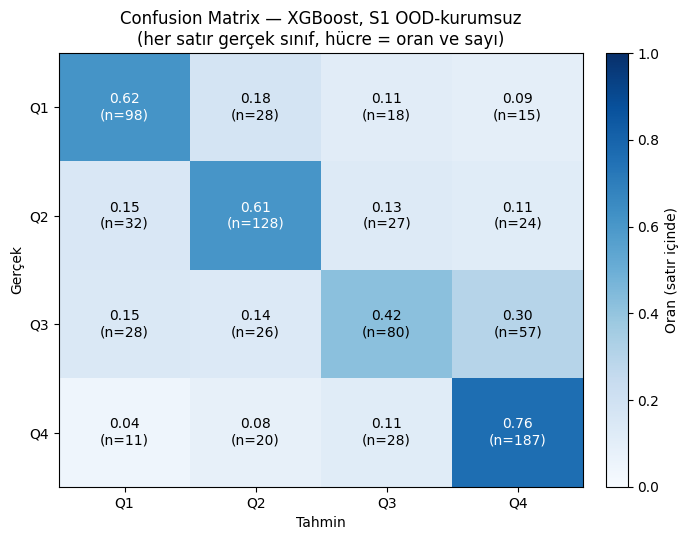

Kaydedildi: 01_confusion_matrix.png


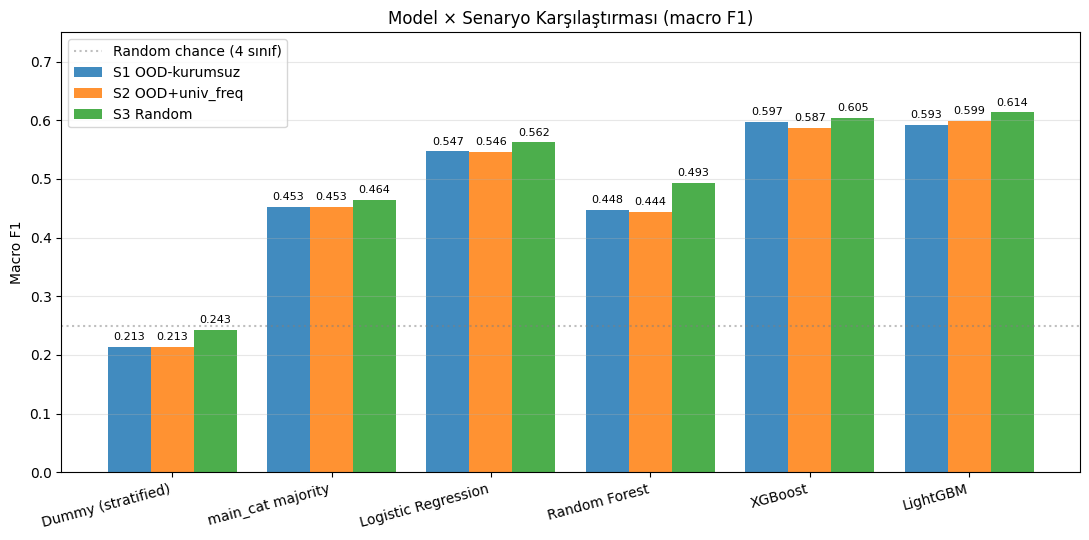

Kaydedildi: 02_model_comparison.png


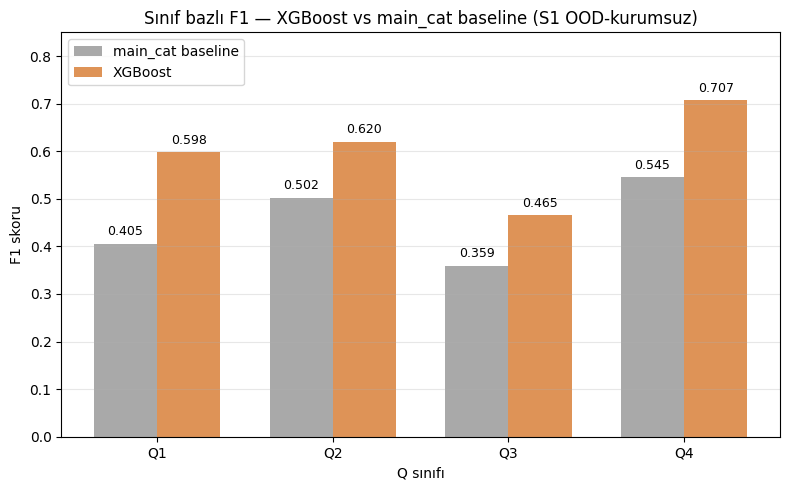

Kaydedildi: 03_per_class_f1.png


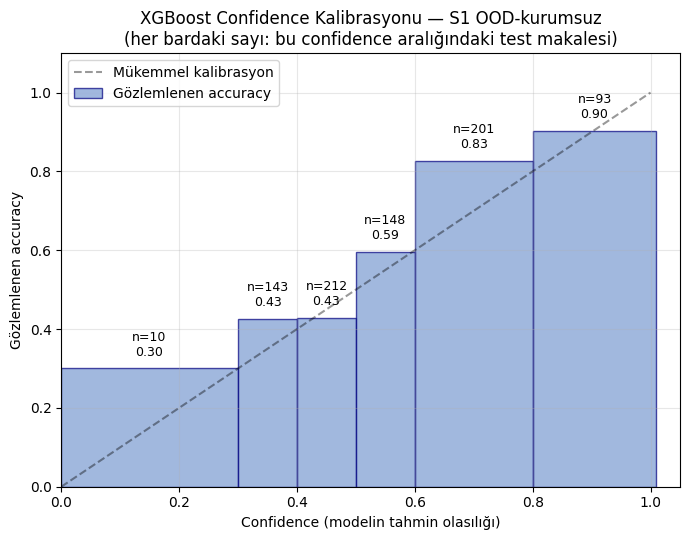

Kaydedildi: 04_confidence_calibration.png


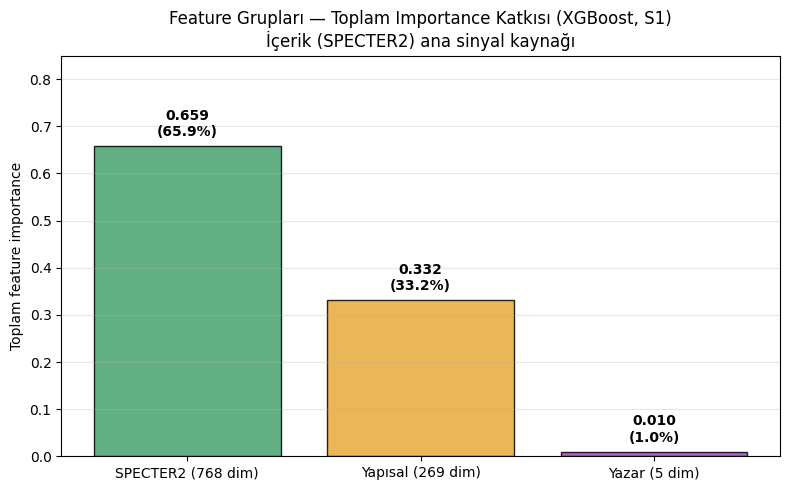

Kaydedildi: 05_feature_importance_groups.png


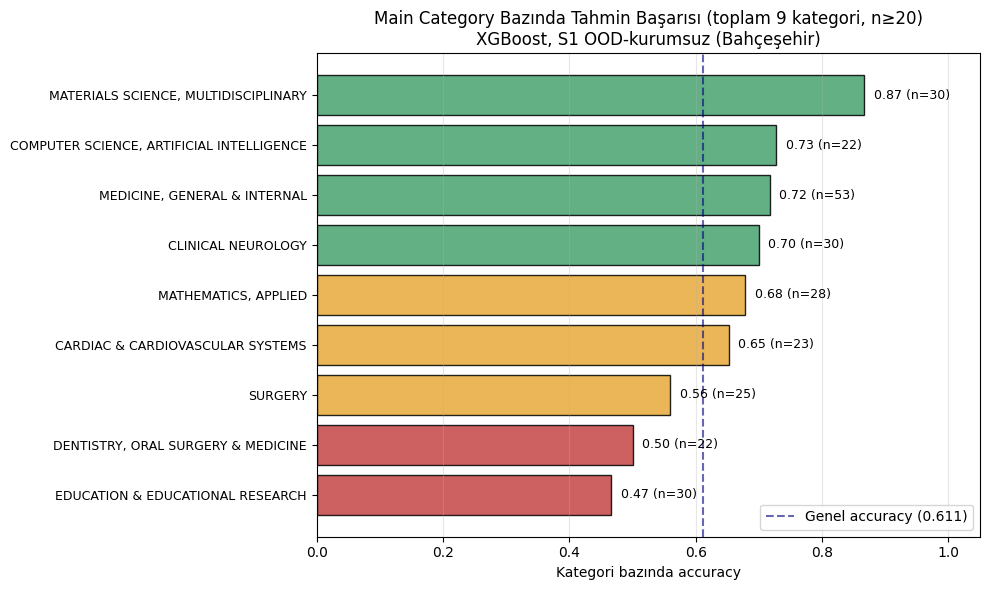

Kaydedildi: 06_category_accuracy.png

6 görsel tamamlandı: C:\Users\Kerem\Desktop\proje\data\shared_outputs\figs


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
from pathlib import Path

FIGS = Path(r"C:\Users\Salih\Desktop\proje\data\shared_outputs\figs")
FIGS.mkdir(parents=True, exist_ok=True)

# Ortak: Q sınıfları için sıralı renk (mavi-yeşil-sarı-kırmızı)
Q_COLORS = ["#2c5aa0", "#48a370", "#e8a93a", "#c54545"]  # Q1, Q2, Q3, Q4
MODEL_COLORS = {
    "Dummy (stratified)":   "#9a9a9a",
    "main_cat majority":    "#6e6e6e",
    "Logistic Regression":  "#7a9ad0",
    "Random Forest":        "#5cb87a",
    "XGBoost":              "#d9803a",
    "LightGBM":             "#a04ac4",
}

# ======================================================================
# 1) CONFUSION MATRIX HEATMAP
# ======================================================================
fig, ax = plt.subplots(figsize=(7, 5.5))
cm = viz_data["cm"]
cm_norm = viz_data["cm_norm"]

im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(classes); ax.set_yticklabels(classes)
ax.set_xlabel("Tahmin"); ax.set_ylabel("Gerçek")
ax.set_title("Confusion Matrix — XGBoost, S1 OOD-kurumsuz\n(her satır gerçek sınıf, hücre = oran ve sayı)")

# Her hücrede oran + ham sayı
for i in range(4):
    for j in range(4):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax.text(j, i, f"{cm_norm[i, j]:.2f}\n(n={cm[i, j]})",
                ha="center", va="center", color=color, fontsize=10)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Oran (satır içinde)")
plt.tight_layout()
plt.savefig(FIGS / "01_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: 01_confusion_matrix.png")

# ======================================================================
# 2) MODEL KIYASLAMA BAR CHART — 6 model × 3 senaryo, macro F1
# ======================================================================
fig, ax = plt.subplots(figsize=(11, 5.5))

models_order = ["Dummy (stratified)", "main_cat majority",
                "Logistic Regression", "Random Forest", "XGBoost", "LightGBM"]
sc_order = ["S1 OOD-kurumsuz", "S2 OOD+univ_freq", "S3 Random"]

x = np.arange(len(models_order))
width = 0.27
sc_keys_map = {
    "S1 OOD-kurumsuz":  "S1_OOD_kurumsuz",
    "S2 OOD+univ_freq": "S2_OOD_univ_freq",
    "S3 Random":        "S3_Random_strat",
}
MODEL_KEY_REV = {v: k for k, v in MODEL_LABELS.items()}

for i, sc_label in enumerate(sc_order):
    sc_key = sc_keys_map[sc_label]
    values = [results[sc_key][MODEL_KEY_REV[m]]["macro_f1"] for m in models_order]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, values, width, label=sc_label, alpha=0.85)
    # Bar üstüne değer yaz
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width()/2, v + 0.008, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8)

ax.axhline(y=0.25, color="gray", linestyle=":", alpha=0.5, label="Random chance (4 sınıf)")
ax.set_xticks(x)
ax.set_xticklabels(models_order, rotation=15, ha="right")
ax.set_ylabel("Macro F1")
ax.set_title("Model × Senaryo Karşılaştırması (macro F1)")
ax.set_ylim(0, 0.75)
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / "02_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: 02_model_comparison.png")

# ======================================================================
# 3) SINIF BAZLI F1 BAR CHART — XGBoost vs main_cat baseline (S1)
# ======================================================================
fig, ax = plt.subplots(figsize=(8, 5))

xgb_f1 = [results["S1_OOD_kurumsuz"]["XGB"]["per_class_f1"][q] for q in classes]
base_f1 = [results["S1_OOD_kurumsuz"]["main_cat_baseline"]["per_class_f1"][q] for q in classes]

x = np.arange(len(classes))
width = 0.36
bars1 = ax.bar(x - width/2, base_f1, width, label="main_cat baseline", 
               color="#9a9a9a", alpha=0.85)
bars2 = ax.bar(x + width/2, xgb_f1, width, label="XGBoost", 
               color="#d9803a", alpha=0.85)

for bars, vals in [(bars1, base_f1), (bars2, xgb_f1)]:
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.012, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_xlabel("Q sınıfı")
ax.set_ylabel("F1 skoru")
ax.set_title("Sınıf bazlı F1 — XGBoost vs main_cat baseline (S1 OOD-kurumsuz)")
ax.set_ylim(0, 0.85)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / "03_per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: 03_per_class_f1.png")

# ======================================================================
# 4) CONFIDENCE KALİBRASYON GRAFİĞİ
# ======================================================================
fig, ax = plt.subplots(figsize=(7, 5.5))
calib = viz_data["calibration"].copy()
# bin merkezi
bin_centers = []
for interval in calib["conf_bin"]:
    if isinstance(interval, pd.Interval):
        bin_centers.append((interval.left + interval.right) / 2)
    else:
        bin_centers.append(0)
calib["bin_center"] = bin_centers

# Mükemmel kalibrasyon (diagonal)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Mükemmel kalibrasyon")

# Bar chart için: x = bin center, y = accuracy
# Bar genişliği bin aralığına göre
widths = []
for interval in calib["conf_bin"]:
    if isinstance(interval, pd.Interval):
        widths.append(interval.right - interval.left)
    else:
        widths.append(0.1)
calib["width"] = widths

bars = ax.bar(calib["bin_center"], calib["accuracy"], width=calib["width"],
              color="#7a9ad0", edgecolor="navy", alpha=0.7, align="center",
              label="Gözlemlenen accuracy")

# Her bin için n değerini bar üstüne yaz
for _, row in calib.iterrows():
    ax.text(row["bin_center"], row["accuracy"] + 0.025,
            f"n={int(row['n'])}\n{row['accuracy']:.2f}",
            ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Confidence (modelin tahmin olasılığı)")
ax.set_ylabel("Gözlemlenen accuracy")
ax.set_title("XGBoost Confidence Kalibrasyonu — S1 OOD-kurumsuz\n"
             "(her bardaki sayı: bu confidence aralığındaki test makalesi)")
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.1)
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / "04_confidence_calibration.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: 04_confidence_calibration.png")

# ======================================================================
# 5) FEATURE IMPORTANCE GRUP BAR CHART
# ======================================================================
fig, ax = plt.subplots(figsize=(8, 5))
group_imp = viz_data["group_imp"]
groups = list(group_imp.keys())
values = list(group_imp.values())
colors = ["#48a370", "#e8a93a", "#a04ac4"]

bars = ax.bar(groups, values, color=colors, alpha=0.85, edgecolor="black")
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.015, f"{v:.3f}\n({v*100:.1f}%)",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Toplam feature importance")
ax.set_title("Feature Grupları — Toplam Importance Katkısı (XGBoost, S1)\n"
             "İçerik (SPECTER2) ana sinyal kaynağı")
ax.set_ylim(0, 0.85)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / "05_feature_importance_groups.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: 05_feature_importance_groups.png")

# ======================================================================
# 6) KATEGORİ BAZINDA ACCURACY BAR CHART (yatay, en iyi + en kötü)
# ======================================================================
cat_acc = viz_data["cat_acc"].copy()
# Top 5 ve bottom 5'i al, eğer toplam 10'dan az ise hepsini
if len(cat_acc) >= 10:
    top5 = cat_acc.head(5)
    bot5 = cat_acc.tail(5)
    combined = pd.concat([bot5, top5])  # önce kötüler, sonra iyiler
    title_extra = " (en iyi 5 + en kötü 5)"
else:
    combined = cat_acc
    title_extra = f" (toplam {len(cat_acc)} kategori, n≥20)"

# Renk: accuracy'ye göre kırmızı→yeşil gradient
def acc_color(acc):
    if acc >= 0.70: return "#48a370"
    if acc >= 0.55: return "#e8a93a"
    return "#c54545"
colors = [acc_color(a) for a in combined["accuracy"]]

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(combined))
bars = ax.barh(y_pos, combined["accuracy"], color=colors, alpha=0.85, edgecolor="black")

# Etiket: kategori adı kısaltılmış
labels = [(c[:42] + "...") if len(c) > 45 else c for c in combined["main_cat"]]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()  # en kötü en üstte

# Bar sonuna n + accuracy
for i, (_, row) in enumerate(combined.iterrows()):
    ax.text(row["accuracy"] + 0.015, i, 
            f"{row['accuracy']:.2f} (n={int(row['n'])})",
            va="center", fontsize=9)

ax.axvline(x=0.611, color="navy", linestyle="--", alpha=0.6, 
           label="Genel accuracy (0.611)")
ax.set_xlabel("Kategori bazında accuracy")
ax.set_title(f"Main Category Bazında Tahmin Başarısı{title_extra}\n"
             "XGBoost, S1 OOD-kurumsuz (Bahçeşehir)")
ax.set_xlim(0, 1.05)
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / "06_category_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: 06_category_accuracy.png")

print(f"\n6 görsel tamamlandı: {FIGS}")